In [ ]:
import numpy as np
np.testing.Tester = np.testing.TestCase
import pandas as pd
import json
import scipy
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from feos.si import * # SI numbers and constants
# from si_units import * # SI numbers and constants

from feos.pcsaft import *
from feos.eos import *


from moth import *

msize=12
mwidth = 2
fsize=16
alpha=0.3
lsize = 2
framewidth = 3
markeredgewidth=3
markeredgewidth_no=10

In [2]:
"""
choose specie, parameter-source and path
"""

saft_paras = "20191105_pure_parameters_feos.json"

name = "propane_bell"
name = "propane"

name = "propane"
name = "butane"
name = "hexane"
#name = "heptane"
#name = "octane"



#name = "nonane"
#name = "dodecane"

#name = "carbondioxide"

#name = "butanol"
#name = "propanol"

#name = "water"
#name = "water_hbond"
#name = "water_hbond_fix"

#name = "water_new2"


savepath = "results_all_four/"

In [3]:
"""
build path to save results
"""
try:
    os.mkdir(savepath)
except:
    None

try:
    os.mkdir(savepath+"/"+name)
except:
    None

In [4]:
"""
load and process data

"""

parameters = PcSaftParameters.from_json(
    [name.split("_")[0]], 
    saft_paras, 
    #search_option="name"
)

M = parameters.pure_records[0].molarweight *(GRAM/MOL)
m = parameters.pure_records[0].model_record.m

ppath = "experimental/"+name+"/"+name+"_viscosity_proc.csv"
if os.path.exists(ppath):
    data = pd.read_csv(ppath)
    print("lload")

ppath = "experimental/"+name+"/"+name+"_diffusion.csv"
if os.path.exists(ppath):
    diff_data = pd.read_csv(ppath)    

ppath = "experimental/"+name+"/"+name+"_thermal_conductivity_proc.csv"
if os.path.exists(ppath):
    tc_data = pd.read_csv(ppath)

ppath = "experimental/"+name+"/"+name+"_speed_of_sound_proc.csv"
if os.path.exists(ppath):
    sos_data = pd.read_csv(ppath)
    print("lload")    

s_res_max = -10
data = data[ data["s_res"] < s_res_max ]
diff_data = diff_data[ diff_data["s_res"] < s_res_max ]
tc_data = tc_data[ tc_data["s_res"] < s_res_max ]
sos_data = sos_data[ sos_data["s_res"] < s_res_max ]

data = data[  data["pressure"] < 2e8  ]
diff_data = diff_data[  diff_data["pressure"] < 2e8  ]
tc_data = tc_data[  tc_data["pressure"] < 2e8  ]
sos_data = sos_data[  sos_data["pressure"] < 2e8  ]


lload
lload


In [5]:
os.path.exists(ppath), ppath

(True, 'experimental/hexane/hexane_speed_of_sound_proc.csv')

In [6]:
poly_dict = {
    "propane": [3.51848530e+00,  8.98719202e-01, -6.57541675e-02,  4.85748207e-03,
       -3.89815685e-02,  3.23990347e-04,  2.68096625e-05],
    "butane": [2.93675606e+00,  6.58606541e-01, -3.54757854e-02,  3.43297168e-03,
       -2.34423967e-02, -3.20780717e-09,  2.77658981e-06],
    "hexane": [  3.201e+00 , 6.538e-01, -2.872e-02,  2.056e-03, -3.439e-02, -2.500e-09 , 9.602e-06],
    "heptane": [3.14259960e+00,  5.87862794e-01, -2.91491603e-02,  2.08778638e-03,
       -1.44664705e-02, -1.24873294e-19, -1.24873294e-19],
    "octane": [ 3.26730119e+00,  6.05701436e-01, -2.67738775e-02,  1.79895834e-03,
       -2.85554249e-02, -8.00307969e-19, -8.00307969e-19],
    "nonane": [ 3.25593263e+00,  5.94314410e-01, -3.34719291e-02,  2.06303415e-03,
       -1.34864713e-02, -7.79506607e-19, -7.79506607e-19],
    "dodecane": [ 3.14613724e+00,  4.33415774e-01, -1.43774533e-02,  8.43063298e-04,
        6.78612430e-03, -9.35159214e-05, -4.08358569e-06 ],
    "propanol":[3.1066556182709726, 0.3339730333762955, 0.009245313934974447, 0.0013849394768765822, -0.047430508899753754, -0.0005883123087159559, -3.303476589905937e-05],
    "butanol": [ 3.09736418e+00,  5.16332669e-01, -1.12147937e-02,  1.86113048e-03,
        -9.89413889e-02,  1.41800551e-07,  2.59356047e-06],
     "carbondioxide": [ 2.43423933e+00,  1.00134140e-01,  9.41409197e-02, -5.46421374e-03,
        8.63269060e-02, -1.07508664e-02,  4.90355962e-04],
     "water": [ 4.02290363e+00,  3.74513465e-01, -1.00705969e-01,  2.27679907e-03,
        1.80066136e-01,  7.67372189e-03,  5.27146621e-05],
    "water_new2": [4.03210064e+00,  3.71941896e-01, -1.03863165e-01,  2.68905680e-03,
        1.76920251e-01,  8.88540130e-03,  9.45182114e-07],      
    "water_hbond": [4.14071517e+00,  3.08348513e-01, -6.26207933e-02,  5.13599738e-03,
        1.60000000e-01,  8.43927589e-06,  1.00000000e-04],
    "water_hbond_fix":[ 4.17987307e+00,  2.73614916e-01, -9.99996458e-02,  1.30869622e-02, 0, 0, 0 ],
}

p = poly_dict[name]
p

[3.201, 0.6538, -0.02872, 0.002056, -0.03439, -2.5e-09, 9.602e-06]

In [7]:
model = EyringEntropyModel( parameters, data=data, data_diffusion=diff_data, 
                 data_tc=tc_data, 
                 data_sos=sos_data, 
                 p=p,
                 penalty_V_f=0.0,
                 penalty_E_act=1,
                 water_hbond=False,)

In [8]:
model.train_full()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 525765693.8169269
        x: [ 3.201e+00  6.408e-01 -1.258e-02  8.904e-04 -2.873e-02
            -4.634e-03  1.885e-04  1.091e+00  9.402e-01  9.226e-01]
      nit: 125
      jac: [-9.624e+06  3.205e+07 -6.433e+05 -1.735e+07  4.102e+07
            -2.313e+07 -1.216e+07  1.159e+06  1.182e+06 -5.627e+05]
     nfev: 2101
     njev: 191
 hess_inv: <10x10 LbfgsInvHessProduct with dtype=float64>


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 525765693.8169269
        x: [ 3.201e+00  6.408e-01 -1.258e-02  8.904e-04 -2.873e-02
            -4.634e-03  1.885e-04  1.091e+00  9.402e-01  9.226e-01]
      nit: 125
      jac: [-9.624e+06  3.205e+07 -6.433e+05 -1.735e+07  4.102e+07
            -2.313e+07 -1.216e+07  1.159e+06  1.182e+06 -5.627e+05]
     nfev: 2101
     njev: 191
 hess_inv: <10x10 LbfgsInvHessProduct with dtype=float64>

In [9]:
model.p_tc, model.p_sos, model.dd

([np.float64(0.940233583028533)],
 [np.float64(0.9226237326779247)],
 [np.float64(1.0905874495190357)])

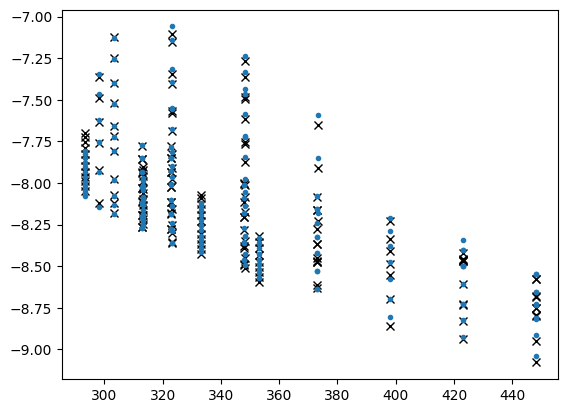

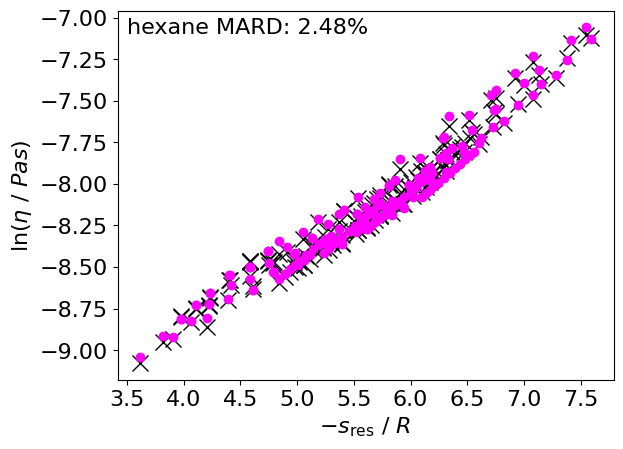

np.float64(2.4750795685717755)

In [10]:
y_pred = model.predict()

plt.plot(model.data["temperature"],np.log(model.data["viscosity"]),"kx")
plt.plot(model.data["temperature"],y_pred,".")
plt.show()
plt.close()

fig, ax = plt.subplots()

plt.plot(-model.data["s_res"]/8.314,np.log(model.data["viscosity"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="magenta",markersize=msize)

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(\eta~/~Pas)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred) - model.data["viscosity"]) / model.data["viscosity"] ))*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  


plt.savefig(savepath+"/"+name+"/"+name+"_viscosity.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_viscosity.pdf",bbox_inches='tight')

plt.show()
plt.close()  


error

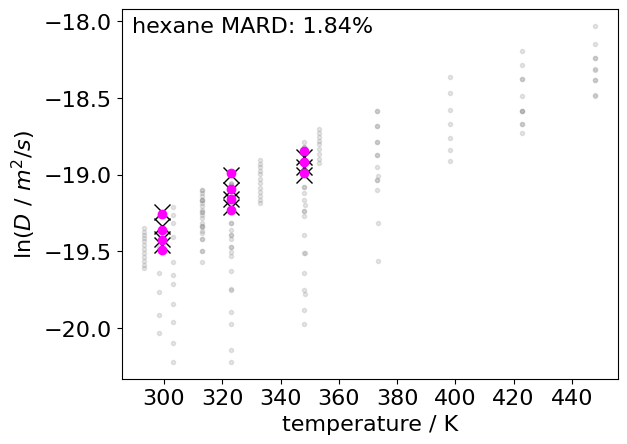

np.float64(1.838408405429336)

In [11]:
"""
predict diffusion

NOTE: leads to error if diffusion is not implemented ;) Then skip...
"""

diff_dat = diff_data

y_pred = model.predict_diffusion()
y_pred_D = model.predict_diffusion(data = diff_dat)

fig, ax = plt.subplots()

plt.plot(diff_dat["temperature"], np.log(diff_dat["D"]),"kx",markersize=msize)
plt.plot(model.data["temperature"],y_pred,".",color="grey",alpha=0.2)
plt.plot(diff_dat["temperature"],y_pred_D,".",color="magenta",markersize=msize)


plt.xlabel(r"temperature / K",fontsize=fsize)
plt.ylabel(r"$\ln(D~/~m^2/s)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_D) - diff_dat["D"]) / diff_dat["D"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_diffusion.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_diffusion.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

In [12]:
model.p_tc, model.p_sos, model.dd

([np.float64(0.940233583028533)],
 [np.float64(0.9226237326779247)],
 [np.float64(1.0905874495190357)])

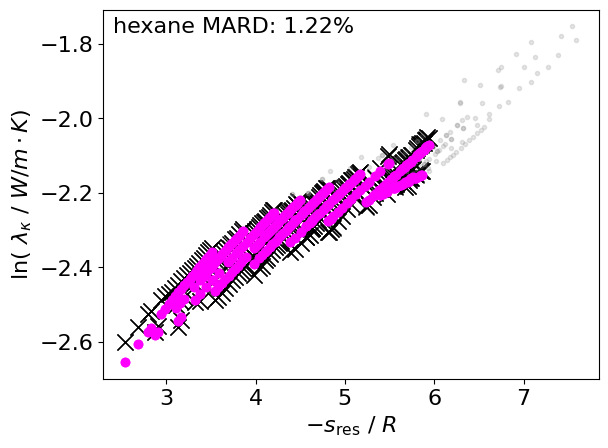

np.float64(1.2240656451380911)

In [13]:
y_pred = model.predict_thermal_conductivity()
y_pred_tc = model.predict_thermal_conductivity(data = tc_data)

fig, ax = plt.subplots()

plt.plot(-tc_data["s_res"]/8.314, np.log(tc_data["thermal_conductivity"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="grey",alpha=0.2)
plt.plot(-tc_data["s_res"]/8.314,y_pred_tc,".",color="magenta",markersize=msize)


plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(~\lambda_\kappa~/~W/m \cdot K)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_tc) - tc_data["thermal_conductivity"]) / tc_data["thermal_conductivity"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

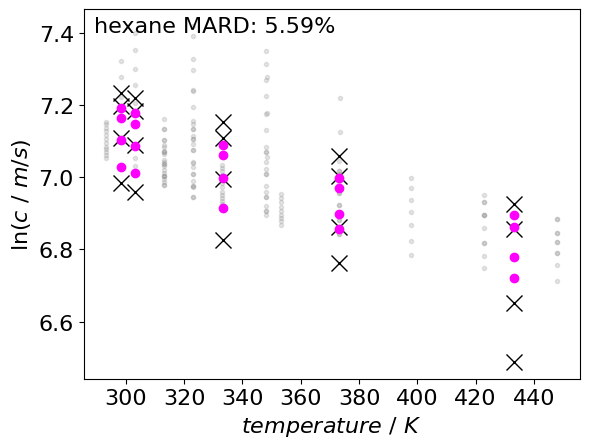

np.float64(5.591763377175408)

In [14]:
y_pred = model.predict_speed_of_sound()
y_pred_sos = model.predict_speed_of_sound(data = sos_data)

fig, ax = plt.subplots()

plt.plot(sos_data["temperature"], np.log(sos_data["speed_of_sound_m_s"]),"kx",markersize=msize)
plt.plot(model.data["temperature"],y_pred,".",color="grey",alpha=0.2)
plt.plot(sos_data["temperature"],y_pred_sos,".",color="magenta",markersize=msize)


plt.xlabel(r"$temperature~/~K$",fontsize=fsize)
plt.ylabel(r"$\ln(c~/~m/s)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_sos) - sos_data["speed_of_sound_m_s"]) / sos_data["speed_of_sound_m_s"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_sos.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_sos.pdf",bbox_inches='tight')


plt.show()
plt.close()

error

In [15]:
name = "butane"


savepath = "results_vtc/"

In [16]:
"""
build path to save results
"""
try:
    os.mkdir(savepath)
except:
    None

try:
    os.mkdir(savepath+"/"+name)
except:
    None

In [17]:
"""
load and process data

"""

parameters = PcSaftParameters.from_json(
    [name.split("_")[0]], 
    saft_paras, 
    #search_option="name"
)

M = parameters.pure_records[0].molarweight *(GRAM/MOL)
m = parameters.pure_records[0].model_record.m

ppath = "experimental/"+name+"/"+name+"_viscosity_proc.csv"
if os.path.exists(ppath):
    data = pd.read_csv(ppath)
    print("lload")


ppath = "experimental/"+name+"/"+name+"_thermal_conductivity_proc.csv"
if os.path.exists(ppath):
    tc_data = pd.read_csv(ppath)


s_res_max = -20
data = data[ data["s_res"] < s_res_max ]
tc_data = tc_data[ tc_data["s_res"] < s_res_max ]

data = data[  data["pressure"] < 2e8  ]
tc_data = tc_data[  tc_data["pressure"] < 2e8  ]



In [18]:
model = EyringEntropyModel( parameters, data=data,
                 data_tc=tc_data, 
                 p=p,
                 penalty_V_f=0.0,
                 penalty_E_act=1,
                 water_hbond=False,)

In [19]:
import random

model.p_tc[0] = 0.99

noise_pct = 0.01

model.p = [x + random.gauss(0, noise_pct * x) for x in model.p ]


In [20]:
model.train_vtc()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 28078703.892147806
        x: [ 3.235e+00  6.191e-01  4.528e-02 -4.881e-03 -8.837e-02
            -1.029e-02  6.868e-04  6.957e-01]
      nit: 115
      jac: [ 1.275e+06 -1.013e+07  1.632e+07  5.007e+07 -2.365e+06
             3.234e+07  3.289e+08  3.834e+06]
     nfev: 2574
     njev: 286
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 28078703.892147806
        x: [ 3.235e+00  6.191e-01  4.528e-02 -4.881e-03 -8.837e-02
            -1.029e-02  6.868e-04  6.957e-01]
      nit: 115
      jac: [ 1.275e+06 -1.013e+07  1.632e+07  5.007e+07 -2.365e+06
             3.234e+07  3.289e+08  3.834e+06]
     nfev: 2574
     njev: 286
 hess_inv: <8x8 LbfgsInvHessProduct with dtype=float64>

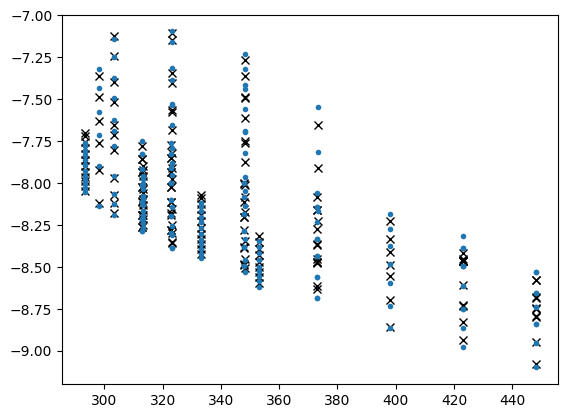

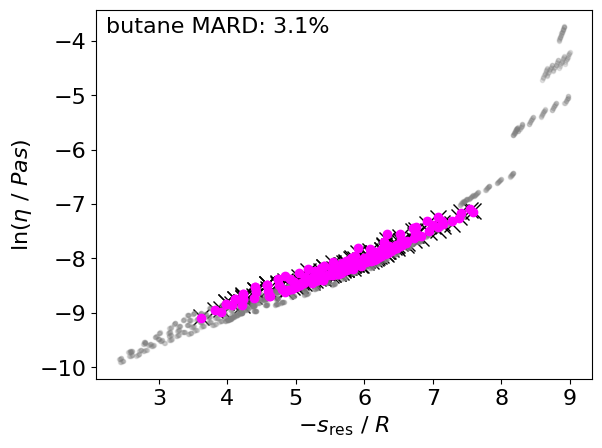

np.float64(3.097487836297986)

In [21]:
y_pred = model.predict()
y_pred_tc = model.predict(data=tc_data)

plt.plot(model.data["temperature"],np.log(model.data["viscosity"]),"kx")
plt.plot(model.data["temperature"],y_pred,".")
plt.show()
plt.close()

fig, ax = plt.subplots()

plt.plot(-model.data["s_res"]/8.314,np.log(model.data["viscosity"]),"kx",markersize=msize)
plt.plot(-tc_data["s_res"]/8.314,y_pred_tc,".",color="grey",alpha=0.2)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="magenta",markersize=msize)

plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(\eta~/~Pas)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred) - model.data["viscosity"]) / model.data["viscosity"] ))*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  


plt.savefig(savepath+"/"+name+"/"+name+"_viscosity.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_viscosity.pdf",bbox_inches='tight')

plt.show()
plt.close()  


error

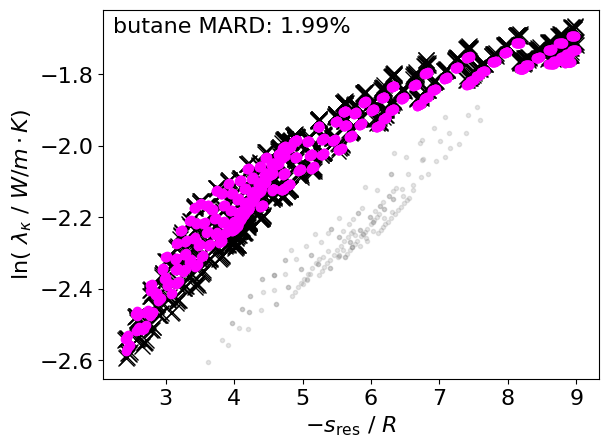

np.float64(1.9941454998079966)

In [22]:
y_pred = model.predict_thermal_conductivity()
y_pred_tc = model.predict_thermal_conductivity(data = tc_data)

fig, ax = plt.subplots()

plt.plot(-tc_data["s_res"]/8.314, np.log(tc_data["thermal_conductivity"]),"kx",markersize=msize)
plt.plot(-model.data["s_res"]/8.314,y_pred,".",color="grey",alpha=0.2)
plt.plot(-tc_data["s_res"]/8.314,y_pred_tc,".",color="magenta",markersize=msize)


plt.xlabel(r"$-s_\text{res}~/~R$",fontsize=fsize)
plt.ylabel(r"$\ln(~\lambda_\kappa~/~W/m \cdot K)$",fontsize=fsize)

error = np.mean(np.abs( ( np.exp(y_pred_tc) - tc_data["thermal_conductivity"]) / tc_data["thermal_conductivity"] ))
error = error*100

plt.text(0.02, 0.98, name.split("_")[0]+' MARD: '+str(round(error,2))+"%",
     fontsize=fsize,
     horizontalalignment='left',
     verticalalignment='top',
     transform = ax.transAxes)

plt.xticks(fontsize=fsize)  
plt.yticks(fontsize=fsize)  

plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.png",bbox_inches='tight')
plt.savefig(savepath+"/"+name+"/"+name+"_thermal_conductivity.pdf",bbox_inches='tight')


plt.show()
plt.close()

error